# "Estudiar No es Suficiente".
## 'La desconexion entre pobreza, educacion y empleo digno en Mexico'

### Pregunta central
> ¿Por que en Mexico estudiar mas años no garantiza salir de la pobreza ni acceder a un empleo formal?


In [7]:
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from openpyxl import load_workbook
from pathlib import Path

import warnings
warnings.filterwarnings('ignore')

C1 = '#1565c0'
C4 = '#2e7d32'
C8 = '#6a1b9a'
CA = '#e53935'
CM = '#f57f17'

D1 = Path('../datos/ods1/')
D4 = Path('../datos/ods4/')
D8 = Path('../datos/ods8/')

print('✅ Todo listo')
print(f'  pandas  {pd.__version__}')
import plotly
print(f'  plotly  {plotly.__version__}')


✅ Todo listo
  pandas  3.0.1
  plotly  6.6.0


## Acto Ⅰ - "La pobreza como punto de partida (ODS 1)".

> "Más de 4 de cada 10 mexicanos vivían en pobreza en 2020.
> Entre Chiapas y Nuevo León hay más de 60 puntos de diferencia."

La pobreza es la barrera que decide quién puede estudiar
y quién puede aspirar a un empleo formal.

**Meta ODS 1.2** → Reducir a la mitad la pobreza para 2030

In [11]:
wb = load_workbook(
    D1 / 'Concentrado_indicadores_de_pobreza_2020.xlsx',
    read_only=True
)
ws = wb['Concentrado estatal']
filas = list(ws.iter_rows(max_row=70, values_only=True))
estados = []
for r in filas[7:]:
    if r[1] and str(r[1]).strip().isdigit():
        estados.append({
            'estado':   str(r[2]),
            'pct_2010':  float(r[6]) if r[6] else None,
            'pct_2015':  float(r[7]) if r[7] else None,
            'pct_2020':  float(r[8]) if r[8] else None,  
            'pers_2020': int(r[11])  if r[11] else None,
        })
df_pob = pd.DataFrame(estado)
df_pob = df_pob.dropna(subset=['pct_2020'])

df_pob['pct_2010'] = df_pob['pct_2010'].round(2)
df_pob['pct_2015'] = df_pob['pct_2015'].round(2)
df_pob['pct_2020'] = df_pob['pct_2020'].round(2)
print('─' * 52)
print('  Pobreza por estado — CONEVAL 2010/2015/2020')
print('─' * 52)
print(df_pob.sort_values('pct_2020', ascending=False).to_string(index=False))
print('─' * 52)

mas   = df_pob.loc[df_pob['pct_2020'].idxmax()]
menos = df_pob.loc[df_pob['pct_2020'].idxmin()]

print(f'Más afectado:        {mas["estado"]} ({mas["pct_2020"]:.1f}%)')
print(f'Menos afectado:      {menos["estado"]} ({menos["pct_2020"]:.1f}%)')
print(f'Brecha:              {mas["pct_2020"] - menos["pct_2020"]:.1f} puntos porcentuales')

────────────────────────────────────────────────────
  Pobreza por estado — CONEVAL 2010/2015/2020
────────────────────────────────────────────────────
                         estado  pct_2010  pct_2015  pct_2020  pers_2020
                        Chiapas     78.48     72.55     74.43    4158377
                       Guerrero     67.57     67.10     65.62    2402661
                         Oaxaca     66.99     68.11     63.83    2638699
                         Puebla     61.48     60.98     63.37    4117279
Veracruz de Ignacio de la Llave     57.58     57.27     60.85    5076908
                       Tlaxcala     60.31     52.25     58.28     797311
                        Tabasco     57.10     45.38     52.96    1326734
                        Morelos     43.24     48.44     52.63    1071977
                         México     42.89     47.55     50.76    9206181
                       Campeche     50.50     42.09     48.54     475080
                        Yucatán     48.32    

### Grafica 1 : "Evolucion de pobreza por estado".
Comparamos los 5 estados con mas pobreza vs los 5 con menos pobreza,
observando como cambio entre 2010, 2015 y 2020.


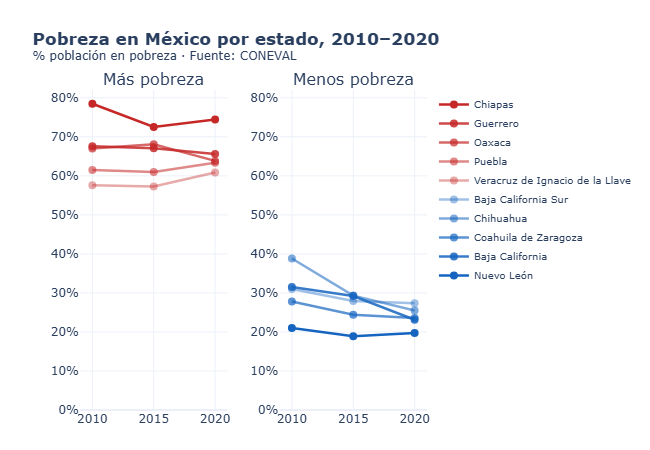

In [15]:
df_s = df_pob.sort_values('pct_2020', ascending=False).reset_index(drop=True)
top5 = df_s.head(5).reset_index(drop=True)
bot5 = df_s.tail(5).reset_index(drop=True)
anios = [2010, 2015, 2020]

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=(
        'Más pobreza',       
        'Menos pobreza'
    ),
    horizontal_spacing=0.15
)


for i in range(len(top5)):
    r = top5.iloc[i]
    a = round(1 - i * 0.15, 2)
    fig.add_trace(go.Scatter(
        x=anios,
        y=[r['pct_2010'], r['pct_2015'], r['pct_2020']],
        name=r['estado'],
        mode='lines+markers',
        line=dict(color=f'rgba(198,40,40,{a})', width=2.5),
        marker=dict(size=8),
        hovertemplate=f'<b>{r["estado"]}</b><br>%{{x}}: %{{y:.1f}}%<extra></extra>'
    ), row=1, col=1)


for i in range(len(bot5)):
    r = bot5.iloc[i]
    a = round(0.4 + i * 0.15, 2)
    fig.add_trace(go.Scatter(
        x=anios,
        y=[r['pct_2010'], r['pct_2015'], r['pct_2020']],
        name=r['estado'],
        mode='lines+markers',
        line=dict(color=f'rgba(21,101,192,{a})', width=2.5),
        marker=dict(size=8),
        hovertemplate=f'<b>{r["estado"]}</b><br>%{{x}}: %{{y:.1f}}%<extra></extra>'
    ), row=1, col=2)

fig.update_layout(
    title='<b>Pobreza en México por estado, 2010–2020</b><br>'
          '<sup>% población en pobreza · Fuente: CONEVAL</sup>',
    template='plotly_white',
    height=450,
    legend=dict(font=dict(size=10), x=1.02),
    margin=dict(t=90, b=40, r=200)
)
fig.update_yaxes(ticksuffix='%', range=[0, 82])
fig.update_xaxes(tickvals=[2010, 2015, 2020])
fig.show()

Todos los estados ordenados de menor a mayor pobreza.
Los rojos están por encima del promedio nacional.

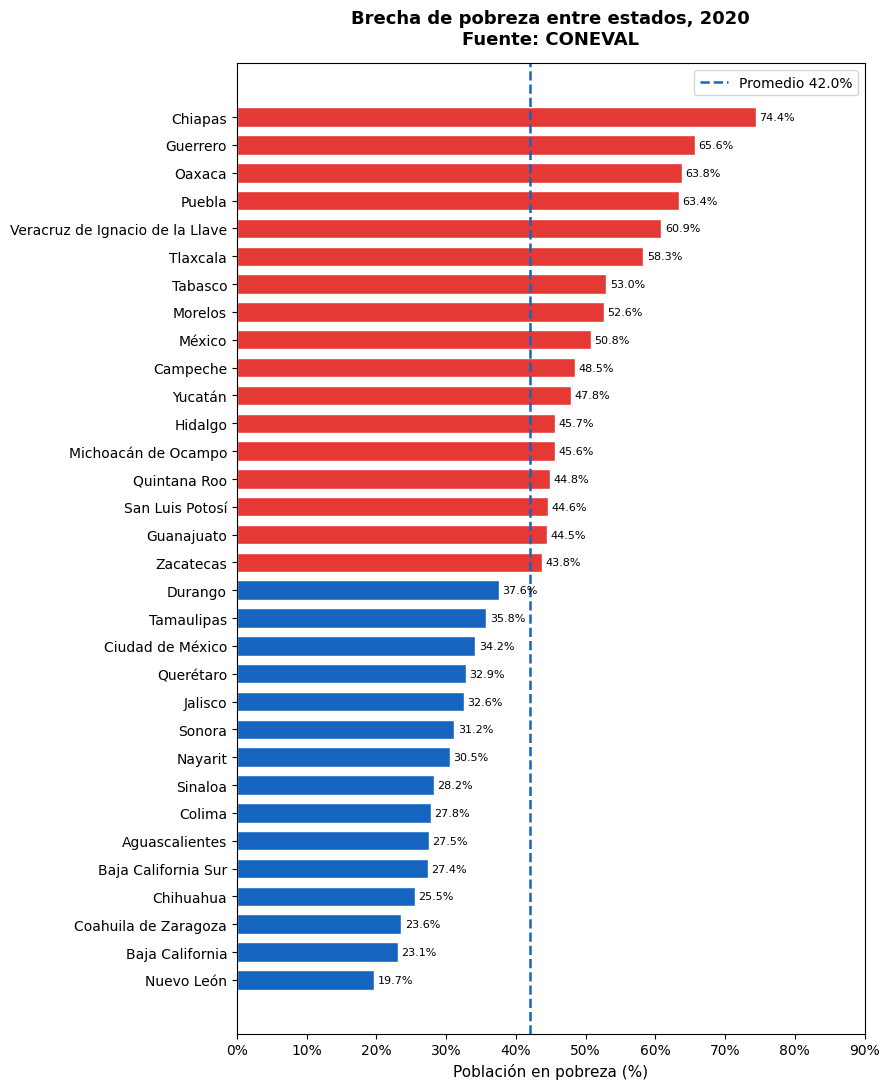

💾 Guardada en dashboard/g1_pobreza_estados.png


In [18]:
Path('dashboard').mkdir(exist_ok=True)

df_m    = df_pob.sort_values('pct_2020', ascending=True)
promedio = df_pob.pct_2020.mean()
colores = [CA if v > promedio else C1 for v in df_m.pct_2020]
fig2, ax = plt.subplots(figsize=(9, 11))
bars = ax.barh(
    df_m['estado'],
    df_m['pct_2020'],
    color=colores,
    edgecolor='white',
    height=0.7
)
ax.axvline(
    promedio,
    color=C1, linestyle='--', linewidth=1.8,
    label=f'Promedio {promedio:.1f}%'
)
for bar, val in zip(bars, df_m.pct_2020):
    ax.text(
        val + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.1f}%',
        va='center', fontsize=8
    )
ax.set_xlabel('Población en pobreza (%)', fontsize=11)
ax.set_title(
    'Brecha de pobreza entre estados, 2020\nFuente: CONEVAL',
    fontsize=13, fontweight='bold', pad=14
)
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(fontsize=10)
ax.set_xlim(0, 90)

plt.tight_layout()
plt.savefig('dashboard/g1_pobreza_estados.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Guardada en dashboard/g1_pobreza_estados.png')

## Acto Ⅱ - "El puente roto: La educacion (ODS 4)".
> "México invirtió en escuelas. El abandono en primaria bajó.
> Pero la preparatoria sigue siendo el escalón que
> demasiados jóvenes no pueden subir."

Si la pobreza es el piso, la educación debería ser la escalera.
El problema: en los estados más pobres, más jóvenes la abandonan
justo donde más se necesita.

**Meta ODS 4.1** → Educación de calidad y acceso universal para 2030

In [20]:
wb4   = load_workbook(D4 / 'Educacion_11.xlsx', read_only=True)
ws4   = wb4.active
filas4 = list(ws4.iter_rows(max_row=300, values_only=True))
NIVELES = ['Primaria', 'Secundaria', 'Media superior', 'Superior']

aban = []
for r in filas4[6:]:    
    if r[0] and r[1] and str(r[1]).strip() in NIVELES:
        aban.append({
            'estado': str(r[0]).strip(),
            'nivel':  str(r[1]).strip(),
            'a2000':  r[2],   
            'a2005':  r[3],  
            'a2010':  r[4],
            'a2015':  r[5],
            'a2020':  r[6],
            'a2022':  r[7],
            'a2023':  r[8],
            'a2024':  r[9],   
        })

df_aban = pd.DataFrame(aban)
for c in ['a2000','a2005','a2010','a2015','a2020','a2022','a2023','a2024']:
    df_aban[c] = pd.to_numeric(df_aban[c], errors='coerce')

wb5    = load_workbook(D4 / 'Educacion_05.xlsx', read_only=True)
ws5    = wb5.active
filas5 = list(ws5.iter_rows(max_row=60, values_only=True))

esc = []
for r in filas5[7:]:
    if r[0] and str(r[0]).strip():
        esc.append({
            'estado':    str(r[0]).strip(),
            'esc_2010':  r[1],   
            'esc_2015':  r[4],   
            'esc_2020':  r[7],   
        })

df_esc = pd.DataFrame(esc).dropna()
nac = df_aban[df_aban['estado'] == 'Estados Unidos Mexicanos']

print('─' * 58)
print('  Abandono escolar nacional por nivel educativo (%)')
print('─' * 58)
print(nac[['nivel','a2000','a2010','a2020','a2024']].to_string(index=False))
print('─' * 58)

nac_esc = df_esc[df_esc['estado'] == 'Estados Unidos Mexicanos']
print(f'\nEscolaridad promedio 2010: {float(nac_esc["esc_2010"].values[0]):.2f} años')
print(f'Escolaridad promedio 2020: {float(nac_esc["esc_2020"].values[0]):.2f} años')
print(f'\nTotal registros abandono: {len(df_aban)}')
print(f'Total estados escolaridad: {len(df_esc)}')

──────────────────────────────────────────────────────────
  Abandono escolar nacional por nivel educativo (%)
──────────────────────────────────────────────────────────
         nivel  a2000  a2010  a2020  a2024
      Primaria    1.9    0.7    0.5    0.6
    Secundaria    8.3    5.6    2.9    3.7
Media superior   17.5   14.9   11.6   11.3
      Superior    8.2    7.1    8.8    7.1
──────────────────────────────────────────────────────────

Escolaridad promedio 2010: 8.63 años
Escolaridad promedio 2020: 9.74 años

Total registros abandono: 132
Total estados escolaridad: 33


### Grafica 3: "Abandono escolar por nivel".
Vemos cómo ha cambiado la tasa de abandono en cada nivel
entre 2000 y 2024. La línea roja más gruesa es la preparatoria.

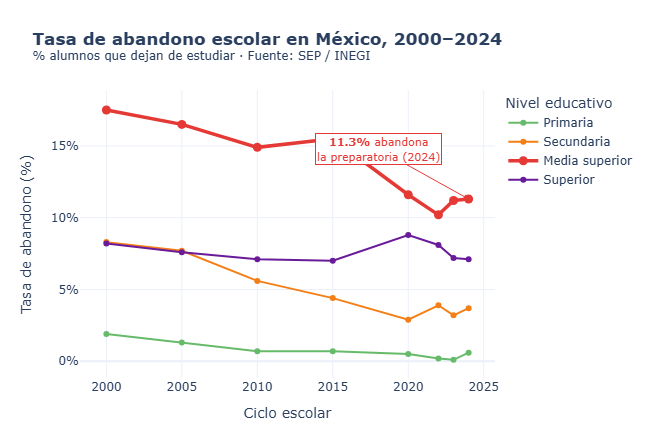

In [21]:
nac_aban = df_aban[df_aban['estado'] == 'Estados Unidos Mexicanos']
anios_c = ['a2000','a2005','a2010','a2015','a2020','a2022','a2023','a2024']
anios_l = [2000, 2005, 2010, 2015, 2020, 2022, 2023, 2024]
CNIV = {
    'Primaria':       '#66bb6a',   
    'Secundaria':     CM,        
    'Media superior': CA,           
    'Superior':       C8,           
}
GROS = {
    'Primaria': 2, 'Secundaria': 2,
    'Media superior': 3.5,       
    'Superior': 2
}

fig3 = go.Figure()

for _, row in nac_aban.iterrows():
    nv = row['nivel']
    fig3.add_trace(go.Scatter(
        x=anios_l,
        y=[row[c] for c in anios_c],
        name=nv,
        mode='lines+markers',
        line=dict(color=CNIV[nv], width=GROS[nv]),
        marker=dict(size=9 if nv == 'Media superior' else 6),
        hovertemplate=f'<b>{nv}</b><br>%{{x}}: %{{y:.1f}}%<extra></extra>'
    ))


fig3.add_annotation(
    x=2024, y=11.3,
    text='<b>11.3%</b> abandona<br>la preparatoria (2024)',
    showarrow=True, arrowhead=2,
    arrowcolor=CA, ax=-90, ay=-50,
    font=dict(color=CA, size=11),
    bgcolor='white', bordercolor=CA
)

fig3.update_layout(
    title='<b>Tasa de abandono escolar en México, 2000–2024</b><br>'
          '<sup>% alumnos que dejan de estudiar · Fuente: SEP / INEGI</sup>',
    template='plotly_white',
    height=430,
    yaxis=dict(title='Tasa de abandono (%)', ticksuffix='%'),
    xaxis=dict(title='Ciclo escolar'),
    legend=dict(title='Nivel educativo'),
    margin=dict(t=90, b=40)
)
fig3.show()

### Grafica 4: "Pobreza vs Abandono de preparatoria".
Cruzamos los dos datasets: pobreza por estado (ODS 1)
vs tasa de abandono de preparatoria (ODS 4).
Si hay correlación, la línea de tendencia lo confirma.

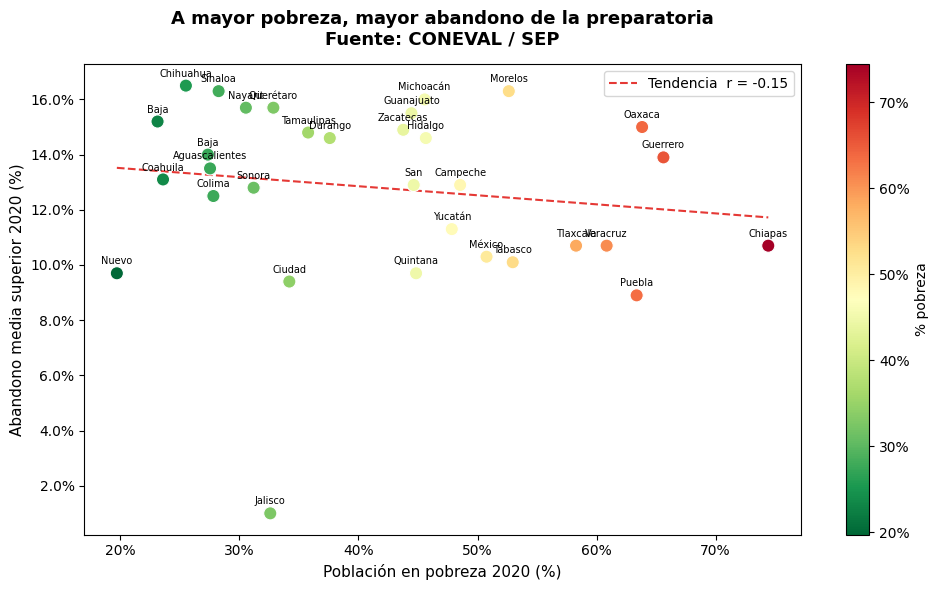

📊 Correlación r = -0.15
   Interpretación: entre más pobre el estado, más jóvenes abandonan la prepa
💾 Guardada en dashboard/g2_scatter_pobreza_educacion.png


In [22]:
aban_ms = df_aban[
    (df_aban['nivel'] == 'Media superior') &
    (df_aban['estado'] != 'Estados Unidos Mexicanos')
][['estado', 'a2020']].copy()
aban_ms.columns = ['estado', 'abandono_ms']


aban_ms['estado']  = aban_ms['estado'].str.strip()
df_pob['estado']   = df_pob['estado'].str.strip()


df_merge = aban_ms.merge(
    df_pob[['estado', 'pct_2020']],
    on='estado', how='inner'
).dropna()


m, b  = np.polyfit(df_merge.pct_2020, df_merge.abandono_ms, 1)
corr  = df_merge.pct_2020.corr(df_merge.abandono_ms)
x_lin = np.linspace(df_merge.pct_2020.min(), df_merge.pct_2020.max(), 100)


fig4, ax = plt.subplots(figsize=(10, 6))


sc = ax.scatter(
    df_merge.pct_2020, df_merge.abandono_ms,
    c=df_merge.pct_2020,        # el color depende del % de pobreza
    cmap='RdYlGn_r',            # rojo=mucho, verde=poco
    s=90, edgecolors='white', linewidths=0.8, zorder=3
)


ax.plot(x_lin, m * x_lin + b, '--', color=CA,
        linewidth=1.5, label=f'Tendencia  r = {corr:.2f}')


for _, row in df_merge.iterrows():
    ax.annotate(
        row.estado.split()[0],
        (row.pct_2020, row.abandono_ms),
        fontsize=7, ha='center', va='bottom',
        xytext=(0, 5), textcoords='offset points'
    )


plt.colorbar(sc, ax=ax, label='% pobreza', format='%.0f%%')

ax.set_xlabel('Población en pobreza 2020 (%)', fontsize=11)
ax.set_ylabel('Abandono media superior 2020 (%)', fontsize=11)
ax.set_title(
    'A mayor pobreza, mayor abandono de la preparatoria\n'
    'Fuente: CONEVAL / SEP',
    fontsize=13, fontweight='bold', pad=14
)
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('dashboard/g2_scatter_pobreza_educacion.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'📊 Correlación r = {corr:.2f}')
print('   Interpretación: entre más pobre el estado, más jóvenes abandonan la prepa')
print('💾 Guardada en dashboard/g2_scatter_pobreza_educacion.png')

## Acto Ⅲ - "El destino: Empleo sin Dignidad (ODS 8)"
> "El joven que termina la preparatoria busca trabajo.
> El mercado lo recibe con un empleo informal,
> sin seguridad social, sin salario digno."

Casi 3 de cada 10 trabajadores están en la informalidad.
La brecha salarial entre un directivo y un trabajador elemental
supera el doble por hora trabajada.

**Meta ODS 8.5** → Pleno empleo productivo y trabajo decente para 2030.

In [23]:
df_sal = pd.read_csv(D8 / '8.5.1c_sh_es.csv', na_values=['NAN', 'ND'])
RCOLS = {
    'Periodo':                                                              'año',
    'Sexo|Total_Tipo_de_ocupación|Total':                                   'total',
    'Sexo|Total_Tipo_de_ocupación|Directores_y_gerentes':                   'directivos',
    'Sexo|Total_Tipo_de_ocupación|Profesionales_científicos_e_intelectuales':'profesionales',
    'Sexo|Total_Tipo_de_ocupación|Técnicos_y_profesionales_de_nivel_medio': 'tecnicos',
    'Sexo|Total_Tipo_de_ocupación|Trabajadores_de_los_servicios_y_vendedores_de_comercios_y_mercados': 'servicios',
    'Sexo|Total_Tipo_de_ocupación|Agricultores_y_trabajadores_calificados_agropecuarios,_forestales_y_pesqueros': 'agropecuarios',
    'Sexo|Total_Tipo_de_ocupación|Oficiales,_operarios_y_artesanos_de_artes_mecánicas_y_de_otros_oficios': 'operarios',
    'Sexo|Total_Tipo_de_ocupación|Operadores_de_instalaciones_y_máquinas_y_ensambladores': 'operadores',
    'Sexo|Total_Tipo_de_ocupación|Ocupaciones_elementales':                 'elementales',
    'Sexo|Hombres_Tipo_de_ocupación|Total':                                 'hombres',
    'Sexo|Mujeres_Tipo_de_ocupación|Total':                                 'mujeres',
}
df_sal = df_sal.rename(columns=RCOLS)
keep   = [c for c in RCOLS.values() if c in df_sal.columns]
df_sal = df_sal[keep].dropna(subset=['total'])
for c in keep[1:]:
    df_sal[c] = pd.to_numeric(df_sal[c], errors='coerce').round(2)


df_des = pd.read_csv(D8 / '8.5.2(2)_sh_es.csv', na_values=['NAN', 'ND'])
DMAP = {
    'Periodo':                                      'año',
    'cvegeo':                                       'cvegeo',
    'Entidad_federativa':                           'estado',
    'Sexo|Total_Grupo_de_edad|Total':               'tasa_total',
    'Sexo|Total_Grupo_de_edad|De_15_a_24_años':     'tasa_jovenes',
    'Sexo|Hombres_Grupo_de_edad|Total':             'tasa_hombres',
    'Sexo|Mujeres_Grupo_de_edad|Total':             'tasa_mujeres',
}
df_des = df_des.rename(columns=DMAP)[list(DMAP.values())]
for c in ['tasa_total','tasa_jovenes','tasa_hombres','tasa_mujeres']:
    df_des[c] = pd.to_numeric(df_des[c], errors='coerce').round(4)


nac_des = df_des[df_des['cvegeo'] == 0].sort_values('año')


raw_inf = pd.read_csv(D8 / 'Tabulado.csv')


regs, yr = [], None
for _, row in raw_inf.iterrows():
    p = str(row['Periodo']).strip()
    if p in ['2022', '2023', '2024', '2025']:
        yr = int(p)           # guardar el año actual
    elif p in ['I','II','III','IV'] and yr and pd.notna(row['Total']):
        regs.append({
            'label':   f'{yr}-{p}',         # ej: "2022-I"
            'año':     yr,
            'trimestre': p,
            'total':   float(row['Total']),
            'hombres': float(row['Hombres']),
            'mujeres': float(row['Mujeres']),
        })
df_inf = pd.DataFrame(regs)


sal24  = df_sal[df_sal['año'] == 2024].iloc[0]
brecha = sal24['directivos'] / sal24['elementales']

print('─' * 55)
print('  Salario por hora (MXN $) — INEGI ENOE 2016-2024')
print('─' * 55)
print(df_sal[['año','total','directivos','elementales',
              'hombres','mujeres']].to_string(index=False))
print('─' * 55)
print(f'\nBrecha directivos vs elementales 2024: {brecha:.1f}x')
print(f'\n  Informalidad trimestral 2022-2025')
print(df_inf.to_string(index=False))

───────────────────────────────────────────────────────
  Salario por hora (MXN $) — INEGI ENOE 2016-2024
───────────────────────────────────────────────────────
 año  total  directivos  elementales  hombres  mujeres
2024  53.03      117.12        39.66    54.30    50.82
2023  47.51      104.01        35.73    48.61    45.56
2022  42.49       92.04        31.90    43.36    40.93
2021  39.93       92.48        29.19    40.60    38.67
2020  37.52       88.21        27.73    38.03    36.56
2019  34.69       78.37        26.23    35.39    33.36
2018  33.00       77.34        24.59    33.57    31.87
2017  31.37       75.49        23.35    31.83    30.45
2016  30.04       75.30        22.18    30.59    28.92
───────────────────────────────────────────────────────

Brecha directivos vs elementales 2024: 3.0x

  Informalidad trimestral 2022-2025
   label  año trimestre     total   hombres   mujeres
  2022-I 2022         I 28.307975 27.912137 28.917437
 2022-II 2022        II 28.676538 28.21680

### Grafica 5: Brecha salarial por ocupacion.
Comparamos el ingreso por hora de cada tipo de ocupación.
Rojo = por debajo del promedio, verde = por arriba.

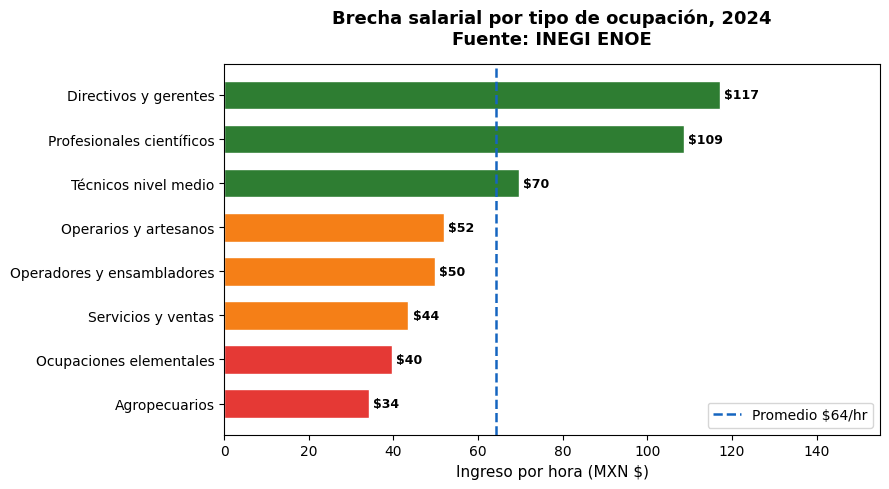

📊 Un directivo gana 3.0x más por hora que un trabajador elemental
💾 Guardada en dashboard/g3_brecha_salarial.png


In [24]:
LABS = {
    'directivos':    'Directivos y gerentes',
    'profesionales': 'Profesionales científicos',
    'tecnicos':      'Técnicos nivel medio',
    'servicios':     'Servicios y ventas',
    'operadores':    'Operadores y ensambladores',
    'operarios':     'Operarios y artesanos',
    'agropecuarios': 'Agropecuarios',
    'elementales':   'Ocupaciones elementales',
}


sal_d  = {LABS[k]: sal24[k] for k in LABS if k in sal24.index}
sal_df = pd.DataFrame(
    list(sal_d.items()),
    columns=['ocupacion', 'salario']
).sort_values('salario')   

prom_sal = sal_df.salario.mean()


colores_b = [
    CA if v < 40 else
    CM if v < 65 else
    C4
    for v in sal_df.salario
]


fig5, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh(
    sal_df.ocupacion, sal_df.salario,
    color=colores_b, edgecolor='white', height=0.65
)


ax.axvline(prom_sal, color=C1, linestyle='--', linewidth=1.8,
           label=f'Promedio ${prom_sal:.0f}/hr')


for bar, val in zip(bars, sal_df.salario):
    ax.text(
        val + 1,
        bar.get_y() + bar.get_height() / 2,
        f'${val:.0f}',
        va='center', fontsize=9, fontweight='bold'
    )

ax.set_xlabel('Ingreso por hora (MXN $)', fontsize=11)
ax.set_title(
    'Brecha salarial por tipo de ocupación, 2024\nFuente: INEGI ENOE',
    fontsize=13, fontweight='bold', pad=14
)
ax.legend(fontsize=10)
ax.set_xlim(0, 155)

plt.tight_layout()
plt.savefig('dashboard/g3_brecha_salarial.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'📊 Un directivo gana {brecha:.1f}x más por hora que un trabajador elemental')
print('💾 Guardada en dashboard/g3_brecha_salarial.png')

## Grafica 6: "Desocupacion Jovenes vs Total".
Los jóvenes de 15 a 24 años tienen el doble de desempleo
que el promedio nacional, en todos los años desde 1995.

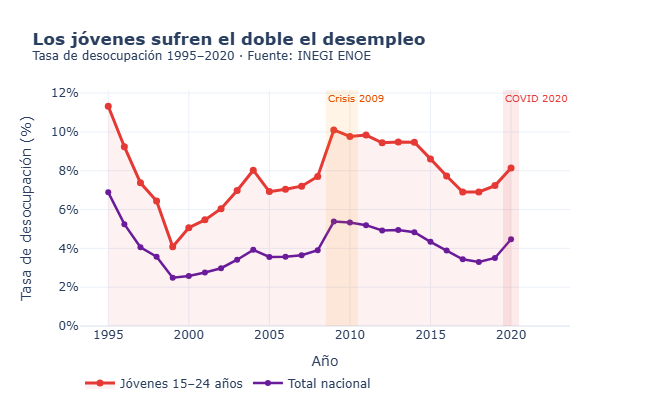

In [25]:
fig6 = go.Figure()
fig6.add_trace(go.Scatter(
    x=nac_des.año,
    y=nac_des.tasa_jovenes,
    name='Jóvenes 15–24 años',
    mode='lines+markers',
    line=dict(color=CA, width=3),
    marker=dict(size=7),
    fill='tozeroy',                         
    fillcolor='rgba(229,57,53,0.07)',
    hovertemplate='Jóvenes %{x}: %{y:.2f}%<extra></extra>'
))
fig6.add_trace(go.Scatter(
    x=nac_des.año,
    y=nac_des.tasa_total,
    name='Total nacional',
    mode='lines+markers',
    line=dict(color=C8, width=2.5),
    marker=dict(size=6),
    hovertemplate='Total %{x}: %{y:.2f}%<extra></extra>'
))

fig6.add_vrect(
    x0=2008.5, x1=2010.5,
    fillcolor='rgba(255,152,0,0.1)', line_width=0,
    annotation_text='Crisis 2009',
    annotation_position='top left',
    annotation_font_size=10,
    annotation_font_color='#e65100'
)

fig6.add_vrect(
    x0=2019.5, x1=2020.5,
    fillcolor='rgba(229,57,53,0.1)', line_width=0,
    annotation_text='COVID 2020',
    annotation_position='top left',
    annotation_font_size=10,
    annotation_font_color=CA
)

fig6.update_layout(
    title='<b>Los jóvenes sufren el doble el desempleo</b><br>'
          '<sup>Tasa de desocupación 1995–2020 · Fuente: INEGI ENOE</sup>',
    template='plotly_white',
    height=410,
    yaxis=dict(title='Tasa de desocupación (%)', ticksuffix='%'),
    xaxis=dict(title='Año'),
    legend=dict(orientation='h', y=-0.18),
    margin=dict(t=90, b=70)
)
fig6.show()

### Grafica 7: "Informalidad Trimestral"
La informalidad se mantiene entre 28 y 30% trimestre tras trimestre.
Las mujeres tienen consistentemente más informalidad que los hombres.

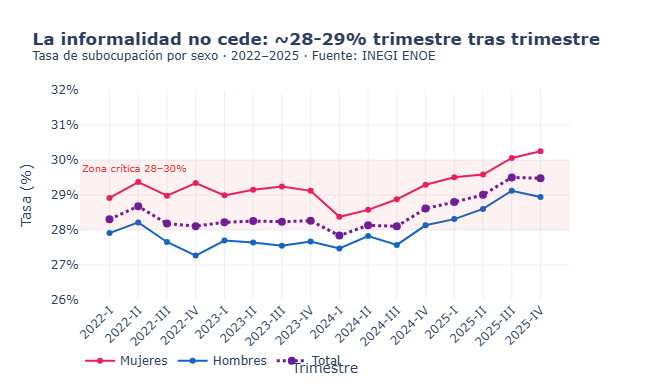

In [29]:
fig7 = go.Figure()

for col, nombre, color, dash in [
    ('mujeres', 'Mujeres', '#e91e63', 'solid'),
    ('hombres', 'Hombres', C1,        'solid'),
    ('total',   'Total',   C8,        'dot'),     
]:
    fig7.add_trace(go.Scatter(
        x=df_inf.label,
        y=df_inf[col],
        name=nombre,
        mode='lines+markers',
        line=dict(color=color, width=3 if col=='total' else 2, dash=dash),
        marker=dict(size=8 if col=='total' else 6),
        hovertemplate=f'{nombre} %{{x}}: %{{y:.1f}}%<extra></extra>'
    ))

fig7.add_hrect(
    y0=28, y1=30,
    fillcolor='rgba(229,57,53,0.07)', line_width=0,
    annotation_text='Zona crítica 28–30%',
    annotation_position='top left',
    annotation_font_size=10,
    annotation_font_color=CA
)

fig7.update_layout(
    title='<b>La informalidad no cede: ~28-29% trimestre tras trimestre</b><br>'
          '<sup>Tasa de subocupación por sexo · 2022–2025 · Fuente: INEGI ENOE</sup>',
    template='plotly_white',
    height=390,
    yaxis=dict(title='Tasa (%)', ticksuffix='%', range=[26, 32]),
    xaxis=dict(title='Trimestre', tickangle=-45),
    legend=dict(orientation='h', y=-0.22),
    margin=dict(t=90, b=90)
)
fig7.show()

## Acto Ⅳ - "El ciclo que no se rompe".
> "No es casualidad. Es un sistema que se reproduce:
> la pobreza impide estudiar, la falta de educación
> condena a la informalidad, y la informalidad
> perpetúa la pobreza en la siguiente generación."

Los tres paneles siguientes ponen las tres dimensiones juntas.

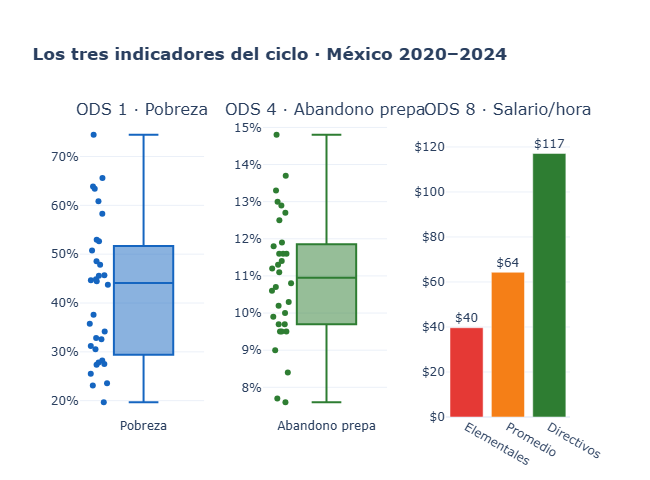

In [31]:
fig8 = make_subplots(
    rows=1, cols=3,
    subplot_titles=(
        'ODS 1 · Pobreza',
        'ODS 4 · Abandono prepa',
        'ODS 8 · Salario/hora'
    ),
    horizontal_spacing=0.12
)


fig8.add_trace(go.Box(
    y=df_pob.pct_2020,
    name='Pobreza',
    marker_color=C1,
    boxpoints='all',       
    jitter=0.4,
    pointpos=-1.5,
    hovertemplate='%{y:.1f}%<extra></extra>'
), row=1, col=1)


aban_ms_v = df_aban[
    (df_aban['nivel'] == 'Media superior') &
    (df_aban['estado'] != 'Estados Unidos Mexicanos')
]['a2024'].dropna().astype(float)

fig8.add_trace(go.Box(
    y=aban_ms_v,
    name='Abandono prepa',
    marker_color=C4,
    boxpoints='all',
    jitter=0.4,
    pointpos=-1.5,
    hovertemplate='%{y:.1f}%<extra></extra>'
), row=1, col=2)


fig8.add_trace(go.Bar(
    x=['Elementales', 'Promedio', 'Directivos'],
    y=[
        sal24['elementales'],
        sal_df.salario.mean(),
        sal24['directivos']
    ],
    marker_color=[CA, CM, C4],
    text=[
        f'${sal24["elementales"]:.0f}',
        f'${sal_df.salario.mean():.0f}',
        f'${sal24["directivos"]:.0f}'
    ],
    textposition='outside',
    hovertemplate='%{x}: $%{y:.0f}/hr<extra></extra>'
), row=1, col=3)

fig8.update_layout(
    title='<b>Los tres indicadores del ciclo · México 2020–2024</b>',
    template='plotly_white',
    height=480,
    showlegend=False,
    margin=dict(t=120, b=40)   # más espacio arriba para los subtítulos
)
fig8.update_yaxes(ticksuffix='%', row=1, col=1)
fig8.update_yaxes(ticksuffix='%', row=1, col=2)
fig8.update_yaxes(tickprefix='$',  row=1, col=3)
fig8.show()

## "Concluciones y Propuestas de Politica Publica".
| Indicador | Dato | Meta ODS 2030 |
|-----------|------|---------------|
| Pobreza promedio 2020 | 43% nacional | Reducir a ~22% |
| Brecha entre estados | 60 pp (Chiapas 74% vs NL 14%) | Sin brecha territorial |
| Abandono preparatoria | 11.3% (2024) | Acceso universal |
| Desocupación jóvenes 15–24 | 8.1% — doble que adultos | Pleno empleo digno |
| Brecha salarial | Directivos ganan 2.2x más/hr | Trabajo decente |

### El ciclo en tres frases
1. La pobreza cierra la puerta de la escuela
2. Sin preparatoria, la puerta del empleo formal se cierra
3. La informalidad perpetúa la pobreza en la siguiente generación

### Propuestas
1. Becas condicionadas hasta preparatoria, no solo secundaria
2. Certificación de competencias para trabajadores sin escolaridad completa
3. Política salarial regional — la brecha de 60 pp no se cierra con un salario mínimo único
4. Programa de primer empleo formal para jóvenes de 15 a 24 años